In [36]:
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


Import Libraries

In [37]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

Load Preprocessed Data

In [38]:
import joblib
X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

preprocessor = joblib.load("preprocessor.pkl")

print(X_train.shape)
print(X_test.shape)

(26074, 85)
(6519, 85)


Verify Target Distribution

In [39]:
print("Training Target Distribution")
print(y_train.value_counts())
print("\nTesting Target Distribution")
print(y_test.value_counts())

Training Target Distribution
dropout_target
0    17949
1     8125
Name: count, dtype: int64

Testing Target Distribution
dropout_target
0    4488
1    2031
Name: count, dtype: int64


Create Evaluation Function

In [40]:
def evaluate_model(model, X_test, y_test):
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:,1]
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction)
    recall = recall_score(y_test, prediction)
    f1 = f1_score(y_test, prediction)
    roc = roc_auc_score(y_test, probability)

    print(model.__class__.__name__)
    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))
    print("ROC AUC  :", round(roc,4))
    print("\nClassification Report")
    print(classification_report(y_test,prediction))
    cm = confusion_matrix(y_test,prediction)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()
    return [
        model.__class__.__name__,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

Train Logistic Regression

In [41]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

LogisticRegression
Accuracy : 0.8144
Precision: 0.7746
Recall   : 0.5702
F1 Score : 0.6568
ROC AUC  : 0.8434

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4488
           1       0.77      0.57      0.66      2031

    accuracy                           0.81      6519
   macro avg       0.80      0.75      0.76      6519
weighted avg       0.81      0.81      0.81      6519



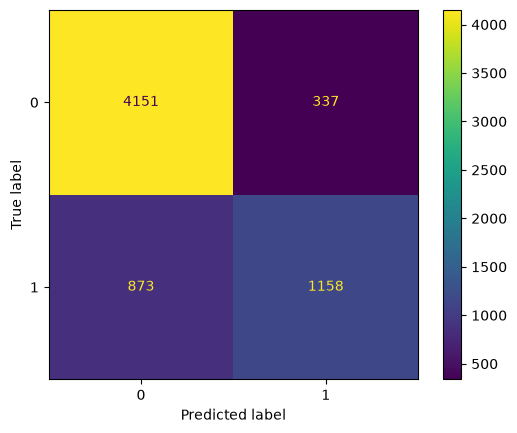

In [42]:
#Evaluate
lr_result = evaluate_model(
    lr,
    X_test,
    y_test
)

Train Decision Tree

In [43]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

DecisionTreeClassifier
Accuracy : 0.7523
Precision: 0.602
Recall   : 0.6046
F1 Score : 0.6033
ROC AUC  : 0.712

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      4488
           1       0.60      0.60      0.60      2031

    accuracy                           0.75      6519
   macro avg       0.71      0.71      0.71      6519
weighted avg       0.75      0.75      0.75      6519



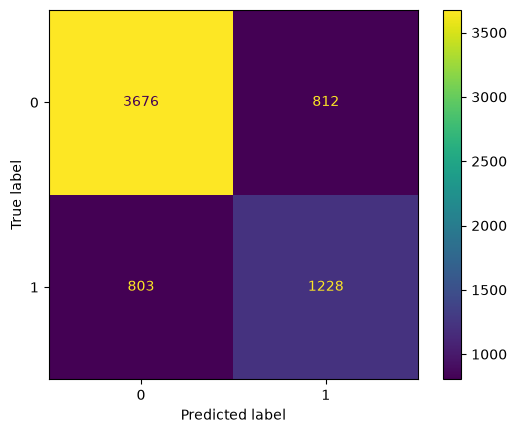

In [44]:
#Evaluate
dt_result = evaluate_model(
    dt,
    X_test,
    y_test
)

Train Random Forest

In [45]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf.fit(
    X_train,
    y_train

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

RandomForestClassifier
Accuracy : 0.8371
Precision: 0.8004
Recall   : 0.6356
F1 Score : 0.7086
ROC AUC  : 0.8705

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4488
           1       0.80      0.64      0.71      2031

    accuracy                           0.84      6519
   macro avg       0.82      0.78      0.80      6519
weighted avg       0.83      0.84      0.83      6519



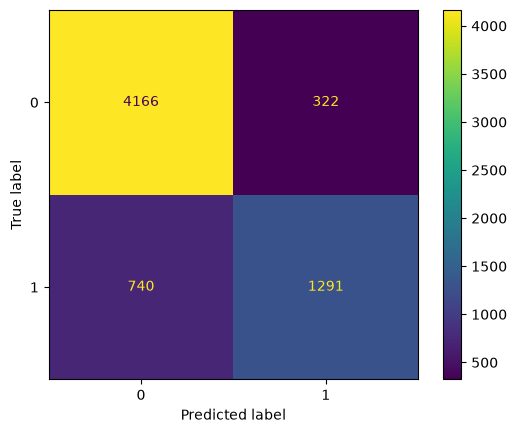

In [46]:
#Evaluate
rf_result = evaluate_model(
    rf,
    X_test,
    y_test
)

Train XGBoost

In [47]:
#Train XGBoot model
xgb = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


XGBClassifier
Accuracy : 0.8354
Precision: 0.7848
Recall   : 0.6499
F1 Score : 0.711
ROC AUC  : 0.8722

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4488
           1       0.78      0.65      0.71      2031

    accuracy                           0.84      6519
   macro avg       0.82      0.78      0.80      6519
weighted avg       0.83      0.84      0.83      6519



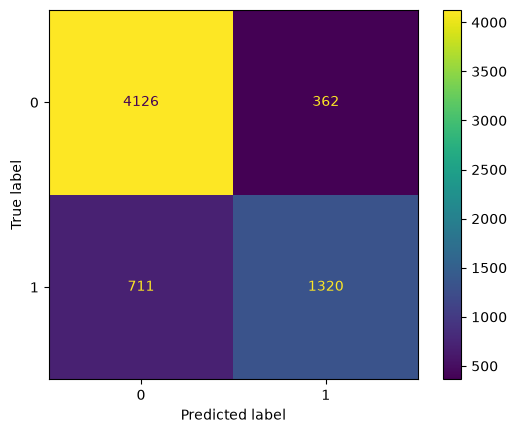

In [48]:
#Evaluate
xgb_result = evaluate_model(
    xgb,
    X_test,
    y_test
)

Train LightGBM

In [49]:
#Train
lgbm = LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 8125, number of negative: 17949
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4163
[LightGBM] [Info] Number of data points in the train set: 26074, number of used features: 84
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.311613 -> initscore=-0.792589
[LightGBM] [Info] Start training from score -0.792589
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,max_depth,6
,n_estimators,200
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,learning_rate,0.1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


LGBMClassifier
Accuracy : 0.8357
Precision: 0.784
Recall   : 0.6524
F1 Score : 0.7122
ROC AUC  : 0.8747

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4488
           1       0.78      0.65      0.71      2031

    accuracy                           0.84      6519
   macro avg       0.82      0.79      0.80      6519
weighted avg       0.83      0.84      0.83      6519



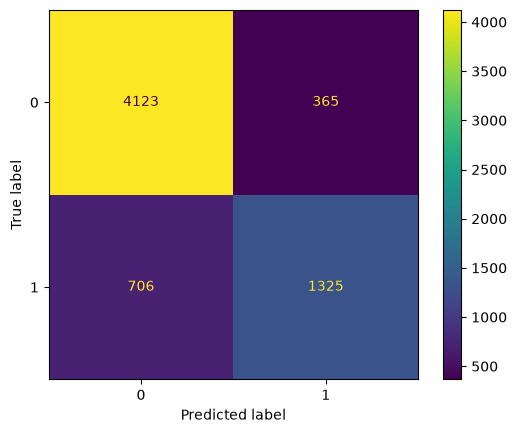

In [50]:
#Evaluate
lgbm_result = evaluate_model(
    lgbm,
    X_test,
    y_test
)

Compare Models

In [51]:
comparison = pd.DataFrame(
    [
        lr_result,
        dt_result,
        rf_result,
        xgb_result,
        lgbm_result
    ],

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]

)

comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LogisticRegression,0.814389,0.774582,0.570162,0.656835,0.843369
1,DecisionTreeClassifier,0.752263,0.601961,0.604628,0.603292,0.712008
2,RandomForestClassifier,0.837092,0.800372,0.635647,0.708562,0.870453
3,XGBClassifier,0.835404,0.784780,0.649926,0.711015,0.872209
4,LGBMClassifier,0.835711,0.784024,0.652388,0.712174,0.874676


Bar Chart Comparison

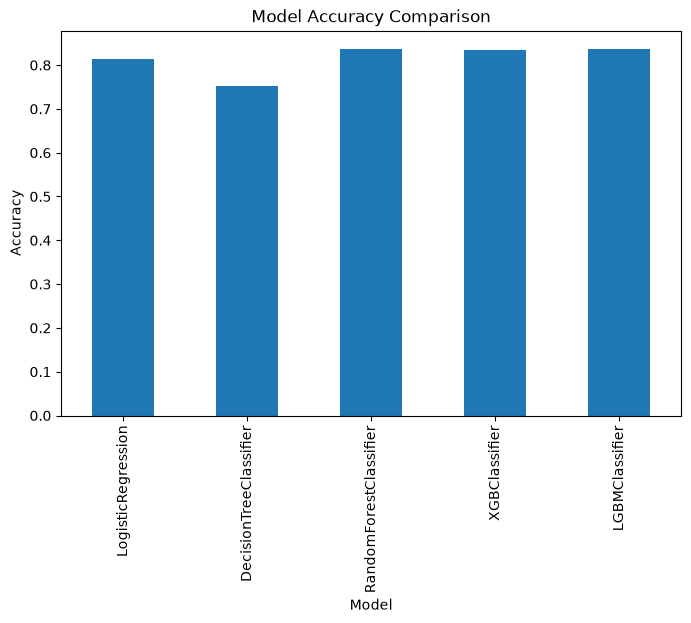

In [52]:
#Accuracy
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

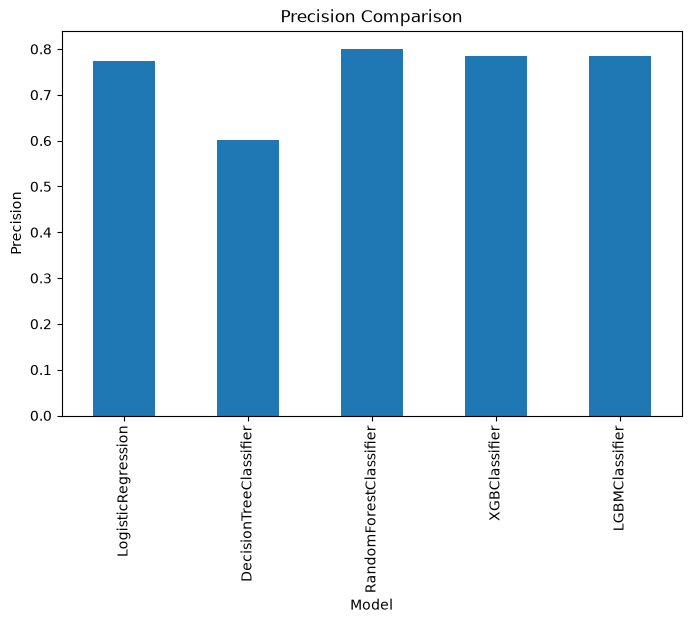

In [53]:
#Precicion
comparison.plot(
    x="Model",
    y="Precision",
    kind="bar",
    figsize=(8,5),
    legend=False
)
plt.ylabel("Precision")
plt.title("Precision Comparison")
plt.show()

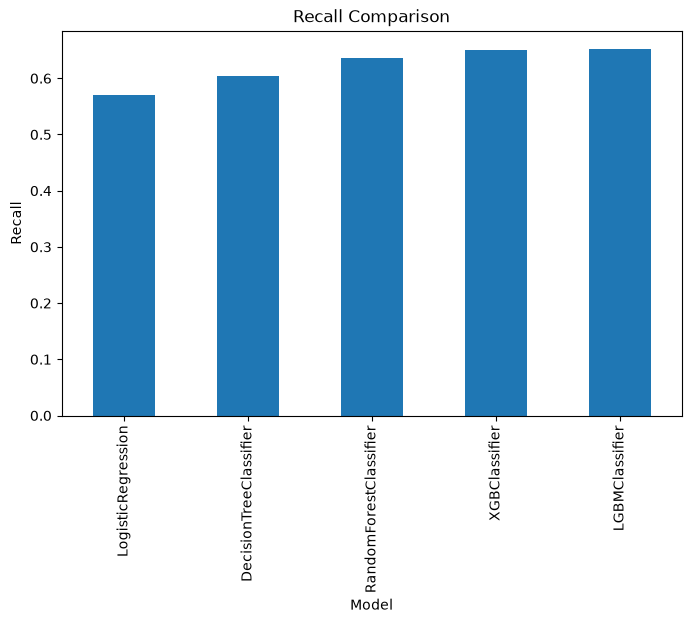

In [54]:
#Recall
comparison.plot(
    x="Model",
    y="Recall",
    kind="bar",
    figsize=(8,5),
    legend=False

)
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.show()

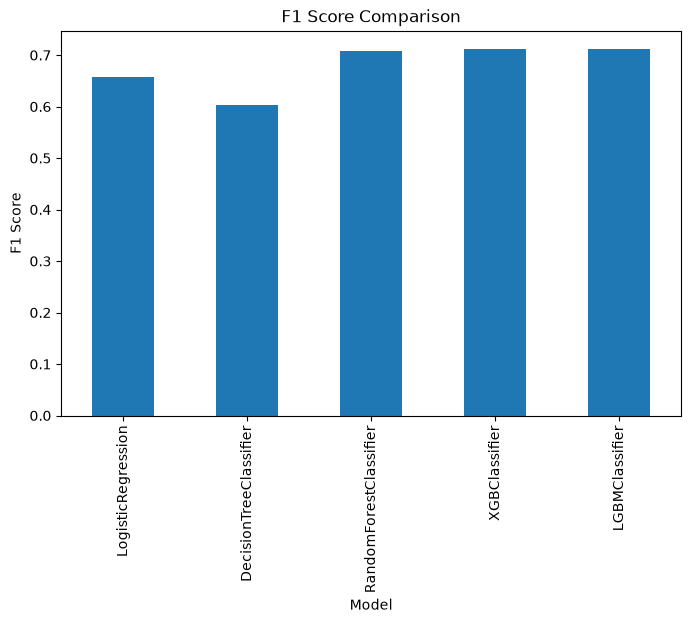

In [55]:
#F1 Score
comparison.plot(
    x="Model",
    y="F1 Score",
    kind="bar",
    figsize=(8,5),
    legend=False

)
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")
plt.show()

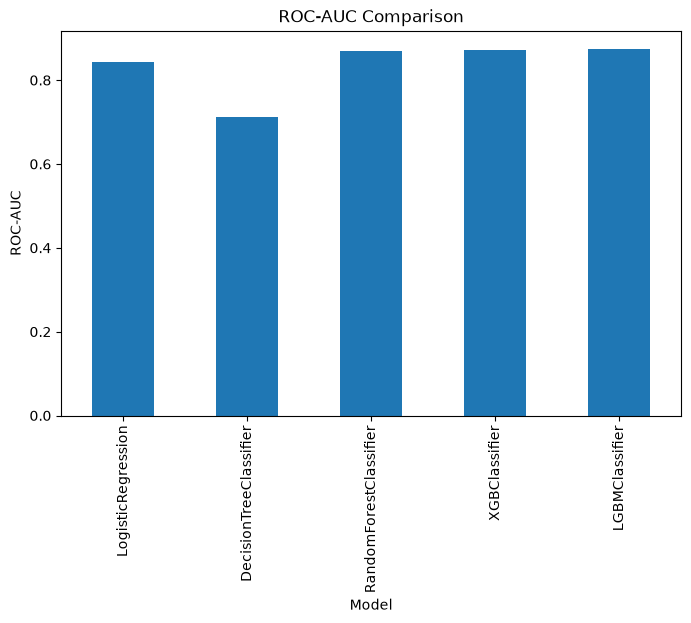

In [56]:
#ROC AUC
comparison.plot(
    x="Model",
    y="ROC AUC",
    kind="bar",
    figsize=(8,5),
    legend=False
)
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison")
plt.show()
plt.show()

Save Best Model

In [57]:
import joblib
joblib.dump(
    xgb,
    "best_baseline_model.pkl"
)

['best_baseline_model.pkl']

Feature Importance (Tree-Based Models)

In [58]:
#Random Forest
importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
6,num__weighted_assessment_score,0.084466
3,num__avg_assessment_score,0.058064
4,num__max_assessment_score,0.052881
5,num__min_assessment_score,0.044767
11,num__total_clicks,0.040589
12,num__active_learning_days,0.039488
21,num__homepage,0.038415
24,num__oucontent,0.034541
33,num__subpage,0.032960
13,num__distinct_resources,0.031967


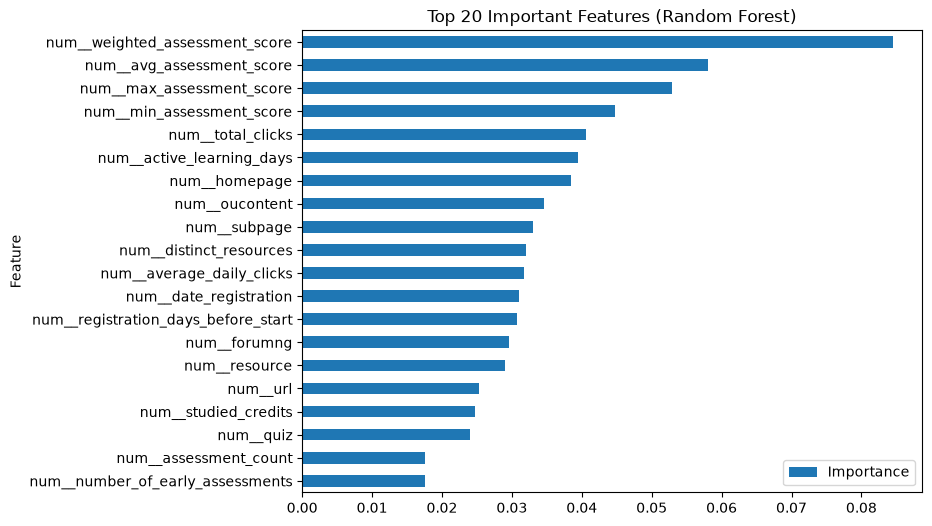

In [59]:
#Plot
importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)
plt.title("Top 20 Important Features (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

XGBoost

In [60]:
importance = pd.DataFrame({
    "Feature": preprocessor.get_feature_names_out(),
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
45,cat__code_module_GGG,0.239661
6,num__weighted_assessment_score,0.117620
2,num__assessment_count,0.045385
39,cat__code_module_AAA,0.026974
38,num__early_assessment_workload,0.025519
4,num__max_assessment_score,0.021665
36,num__number_of_early_assessments,0.021589
49,cat__code_presentation_2014J,0.020959
40,cat__code_module_BBB,0.015331
3,num__avg_assessment_score,0.015311


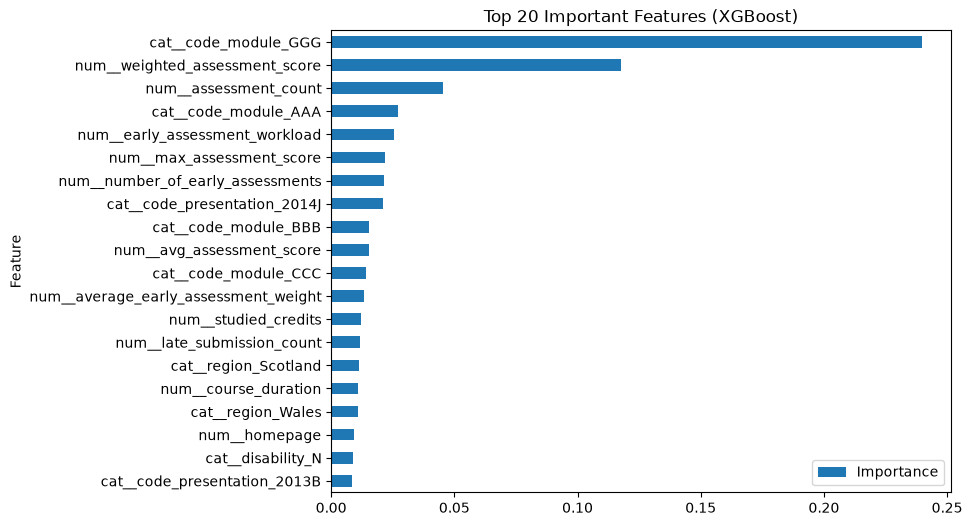

In [61]:
#Plot
importance.head(20).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)
plt.title("Top 20 Important Features (XGBoost)")
plt.gca().invert_yaxis()
plt.show()

ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

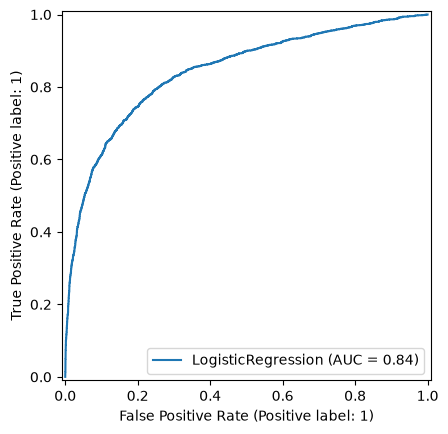

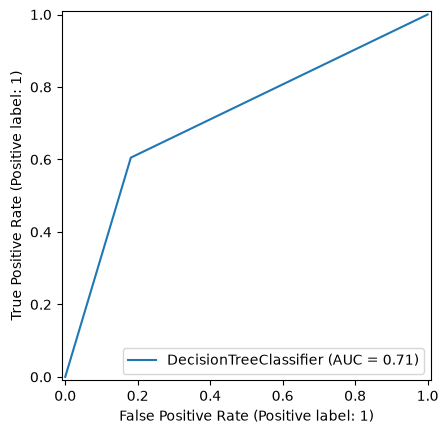

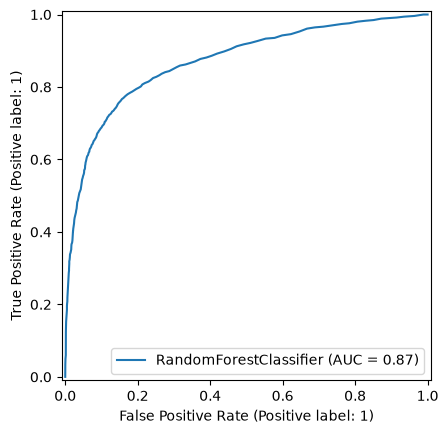

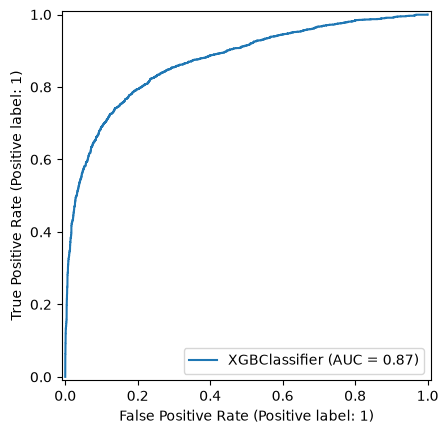

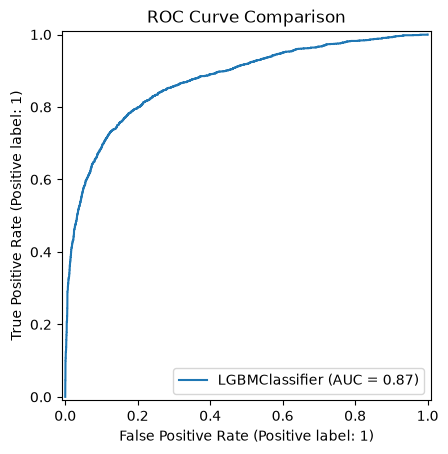

In [62]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8,6))
RocCurveDisplay.from_estimator(lr, X_test, y_test)
RocCurveDisplay.from_estimator(dt, X_test, y_test)
RocCurveDisplay.from_estimator(rf, X_test, y_test)
RocCurveDisplay.from_estimator(xgb, X_test, y_test)
RocCurveDisplay.from_estimator(lgbm, X_test, y_test)
plt.title("ROC Curve Comparison")
plt.show()